# Import libraries

In [45]:
import torch #PyTorch
from torch.utils.data import Dataset, DataLoader #Pytorch Dataset and Dataloader
import torch.nn as nn #Pytorch Neural Network
import torch.nn.functional as F #Pytorch activation function
import torch.optim as optim #Pytorch Optimizer (for training)
import urllib.request #so we can read data from a URL to a file
import os #so we can read data from the file
import tiktoken #Tokenization Library

# PyTorch Basics

First, we will create a dataset to train our model on (same code from the previous lecture)

In [46]:
class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y
    def __getitem__(self, index):
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x, one_y
    def __len__(self):
        return self.labels.shape[0]

In [47]:
X_train = torch.tensor([
[-1.2, 3.1],
[-0.9, 2.9],
[-0.5, 2.6],
[2.3, -1.1],
[2.7, -1.5]
])
y_train = torch.tensor([0, 0, 0, 1, 1])
X_test = torch.tensor([
[-0.8, 2.8],
[2.6, -1.6],
])
y_test = torch.tensor([0, 1])

In [48]:
train_ds = ToyDataset(X_train, y_train)
test_ds = ToyDataset(X_test, y_test)

In [49]:
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0 ,
    drop_last = False
)
test_loader = DataLoader(
    dataset=test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    drop_last = False
)

Second, we build a model

In [50]:
#To build a neural network in Pytorch,
#you need to create a class that inherits from nn.Module
#This class should implement 2 functions: init, and forward
class NeuralNet(nn.Module):
  def __init__(self):
  #This function should call the constructor of ths superclass and then define the layers
    super(NeuralNet, self).__init__()
    self.hidden_layer_1 = nn.Linear(2, 3) #input size is 2 and the first layer has 3 hidden units
    self.hidden_layer_2 = nn.Linear(3, 2) #second layer has 2 hidden units
    self.output_layer = nn.Linear(2, 1) #third layer (output layer) has 1 unit

  def forward(self, x):
  #This function should define how is an output computed from an input through its layers
    out = self.hidden_layer_1(x)
    #pass the input to hidden layer 1
    out = F.relu(out)
    #apply relu activation function to the output of hidden layer
    out = self.hidden_layer_2(out)
    #pass the output of hidden layer 1 (after relu activation) to hidden layer 2
    out = F.relu(out)
    #apply relu activation function
    out = self.output_layer(out)
    #pass the output of hidden layer 2 (after relu activation) to output layer
    out = F.sigmoid(out)
    #apply sigmoid activation function
    return out

Note that our model looks like this
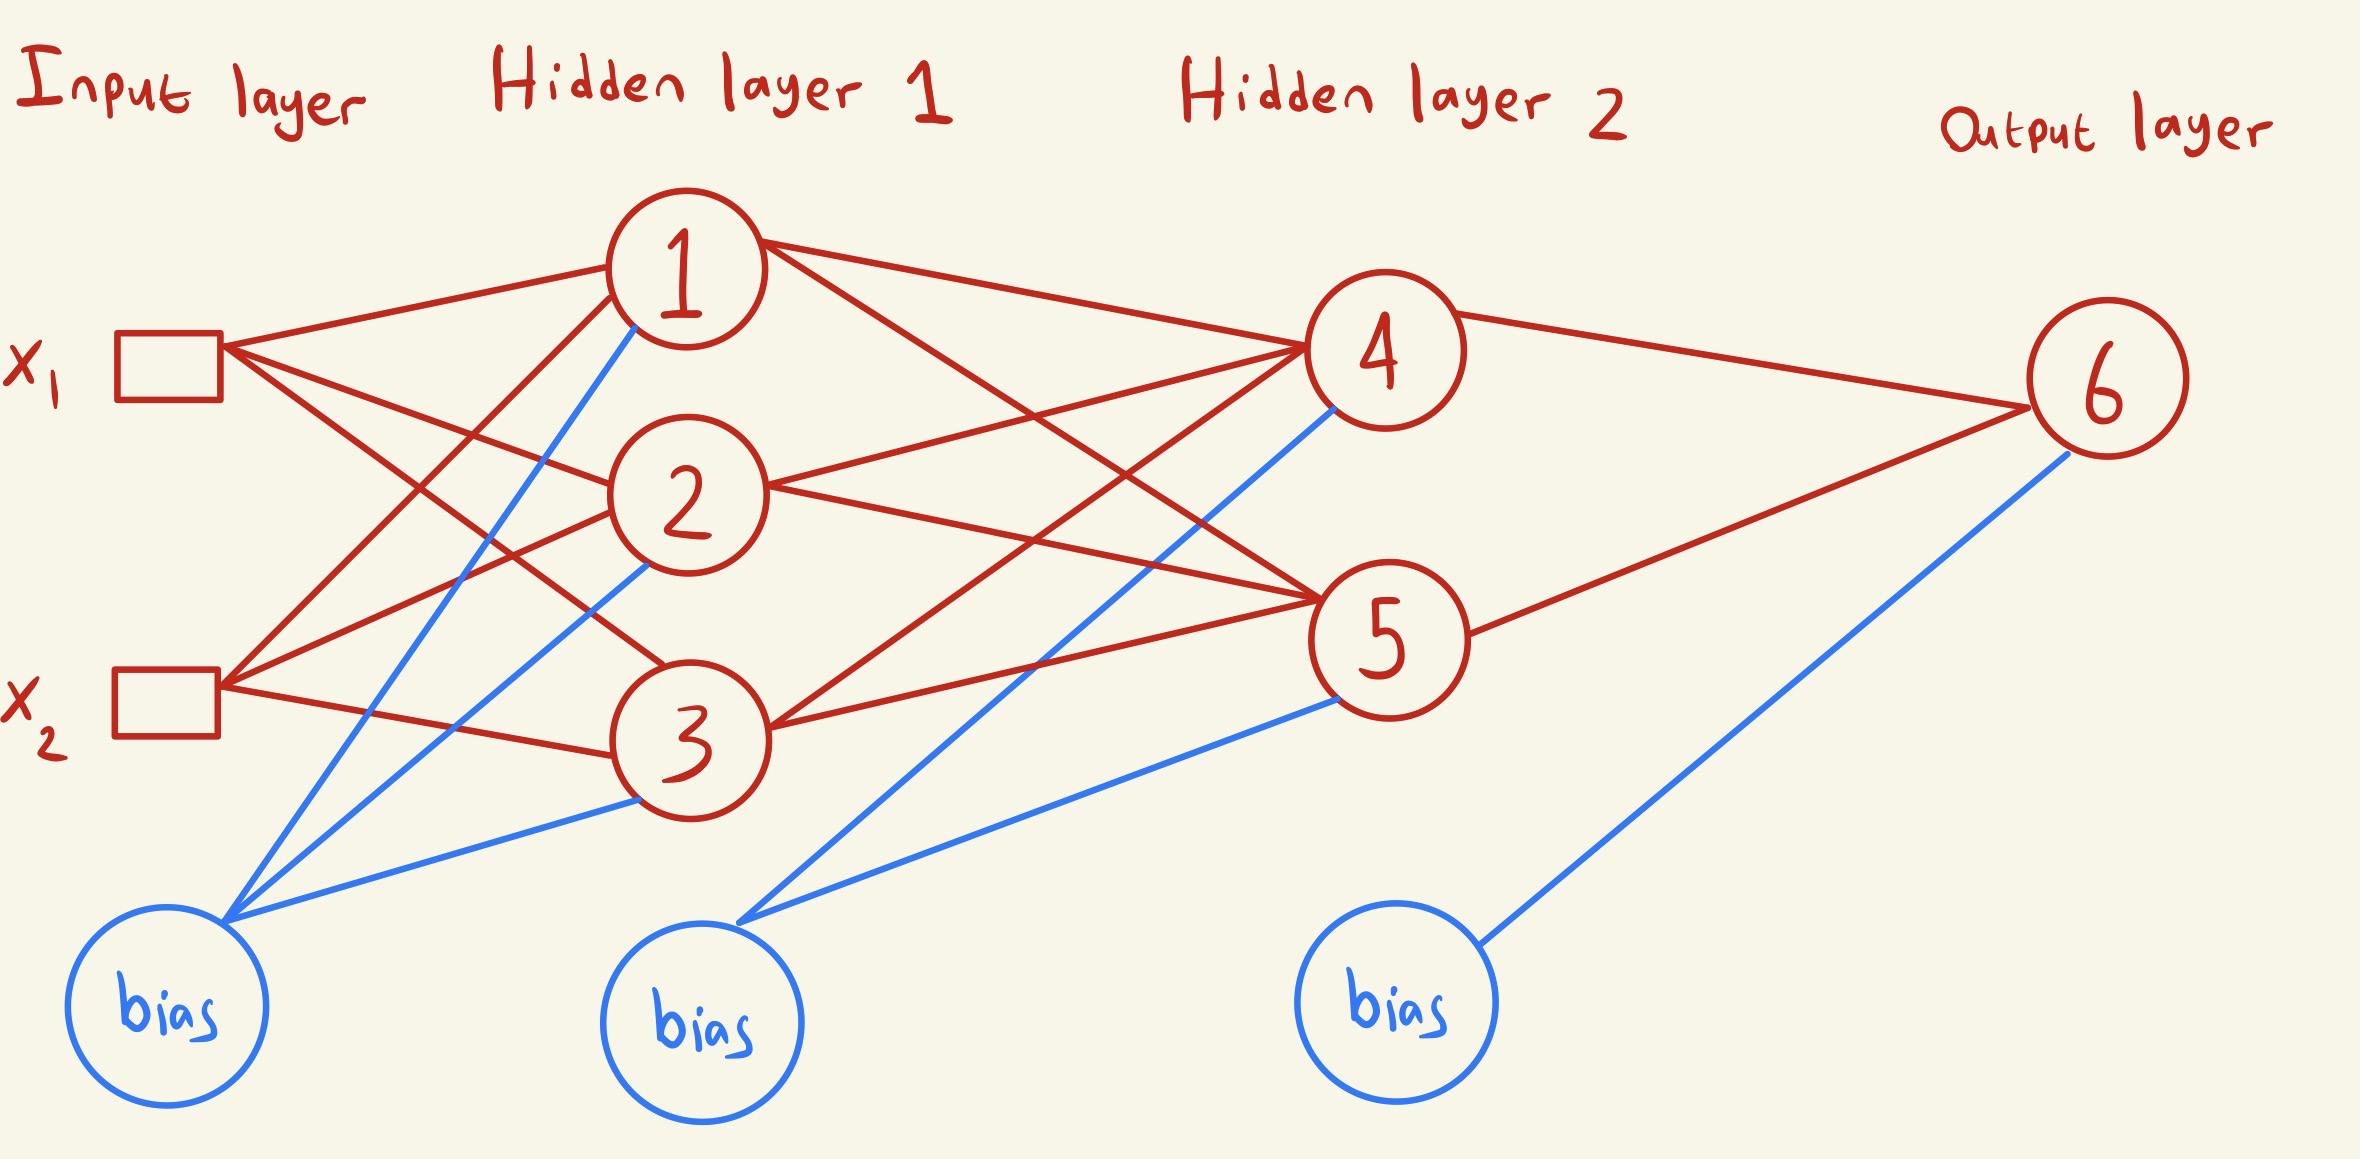

An easier way to implement the same model: (this will not work if the model is not sequential)

In [51]:
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 3),
            nn.ReLU(),
            nn.Linear(3, 2),
            nn.ReLU(),
            nn.Linear(2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

Now let's create a model, and let it predict the labels of the training data

In [52]:
model = NeuralNet()
for input, target in train_loader:
    prediction = model(input) #or model.forward(input)
    print("Input: ",input)
    print("Prediction: ",prediction)

Input:  tensor([[-0.5000,  2.6000],
        [ 2.3000, -1.1000]])
Prediction:  tensor([[0.4029],
        [0.3825]], grad_fn=<SigmoidBackward0>)
Input:  tensor([[ 2.7000, -1.5000],
        [-1.2000,  3.1000]])
Prediction:  tensor([[0.3825],
        [0.4107]], grad_fn=<SigmoidBackward0>)
Input:  tensor([[-0.9000,  2.9000]])
Prediction:  tensor([[0.4076]], grad_fn=<SigmoidBackward0>)


- Now let's define the loss function and optimizer
- We will use binary crossentropy and Adam optimizer

In [53]:
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Now let's train the model

In [54]:
n = 5 #number of epochs
for epoch in range(n):
  model.train() #so model knows that it is being trained
  epoch_loss = 0.0
  for input, target in train_loader:
    prediction = model(input).view(-1) #forward pass
    #note that .view() in pytorch is the same as .reshape() in numpy
    loss = loss_fn(prediction, target.float()) #calculate loss
    epoch_loss += loss.item() #add loss to epoch loss
    optimizer.zero_grad() #gradient = 0
    loss.backward() #calculate gradient
    optimizer.step() #update weights
  print("Epoch: ",epoch," Loss: ",epoch_loss)

Epoch:  0  Loss:  2.0015268325805664
Epoch:  1  Loss:  2.220492422580719
Epoch:  2  Loss:  1.9971819519996643
Epoch:  3  Loss:  2.214105546474457
Epoch:  4  Loss:  2.21044385433197


Now let's test the model

In [55]:
correct = 0
total = 0
model.eval() #tell the model that it is testing
with torch.no_grad(): #no need to track gradients during testing
    for input, target in test_loader:
        prediction = model(input).view(-1) #pass input to model
        prediction = (prediction > 0.5).float() #convert prediction to 0 or 1
        correct += (prediction == target).sum().item() #count the number of correct predictions
        total += target.size(0) #count total number of samples
accuracy = correct / total #calculate accuracy
print("Accuracy:", accuracy)

Accuracy: 0.5


# Downloading Data (same as last lecture)

In [5]:
#Step 1: Read data from URL to file
if not os.path.exists("the-verdict.txt"):
    url = ("https://raw.githubusercontent.com/rasbt/"
           "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
           "the-verdict.txt") #URL where data exists
    file_path = "the-verdict.txt" #file name where we want to store our data
    urllib.request.urlretrieve(url, file_path) #reading data from URL to file

In [56]:
#Step 2: Read data from file to string
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

In [57]:
print(raw_text[:1000])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would have been Rome or Florence.)

"The height of his glory"--that was what the women called it. I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication. "Of course it's going to send the value of my picture 'way up; but I don't think of that, Mr. Rickham--the loss to Arrt is all I think of." The word, on Mrs. Thwing's lips, multiplied its _rs_ as though they were reflected in an endless vista of mirrors. And it was not only the Mrs. Thwings who mourned. Had not the exquisite Hermia Croft, at the last Grafton Gallery show, stopped me before Gisburn's "Moon-dancers" to say, with tears in her eyes: "We shall not look upon its like again"?

Well!--even through th

# Tokenization (same as last lecture)

In [58]:
tokenizer = tiktoken.get_encoding("gpt2")
vocab_size = tokenizer.n_vocab
print(vocab_size)

50257


In [59]:
def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0) # remove batch dimension
  return tokenizer.decode(flat.tolist())

In [60]:
text_to_token_ids("hello",tokenizer)

tensor([[31373]])

In [61]:
token_ids_to_text(torch.tensor([[31373]]),tokenizer)

'hello'

# GPT Dataset and Dataloader (same as last lecture)

In [62]:
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, context_size, stride):
        self.input_ids = []
        self.target_ids = []
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        assert len(token_ids) > context_size, "Number of tokenized inputs must at least be equal to context_size+1"
        for i in range(0, len(token_ids) - context_size, stride):
            input_chunk = token_ids[i:i + context_size]
            target_chunk = token_ids[i + 1: i + context_size + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
    def __len__(self):
        return len(self.input_ids)
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [63]:
def create_dataloader_v1(txt, batch_size=4, context_size=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, context_size, stride)
    dataloader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )
    return dataloader

# Setting up Model Hyperparameters

In [64]:
GPT_CONFIG = {
"vocab_size": vocab_size, # Vocabulary size
"context_length": 256, # Context length
"emb_dim": 768, # Embedding dimension
"n_heads": 12, # Number of attention heads
"n_layers": 12, # Number of layers
"drop_rate": 0.1, # Dropout rate
"qkv_bias": False # Query-Key-Value bias
}

# Splitting Data into training and validation

Specify Training/Validation Ratio

In [67]:
train_ratio = 0.90
split_idx = int(train_ratio * len(raw_text))
train_data = raw_text[:split_idx]
val_data = raw_text[split_idx:]

Now let's create dataloaders for each data

In [68]:
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    context_size=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    context_size=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

Now let's print some statistics

In [69]:
total_train_characters = len(train_data)
total_train_tokens = len(tokenizer.encode(train_data))
print("Train Characters :", total_train_characters)
print("Train Tokens :", total_train_tokens)
print("="*100)
total_val_characters = len(val_data)
total_val_tokens = len(tokenizer.encode(val_data))
print("Validation Characters:", total_val_characters)
print("Validation Tokens:", total_val_tokens)
print("="*100)
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
    break
print("="*100)
print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)
    break

Train Characters : 18431
Train Tokens : 4612
Validation Characters: 2048
Validation Tokens: 534
Train loader:
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


# Building the GPT Model

Note that the GPT2 model looks like this
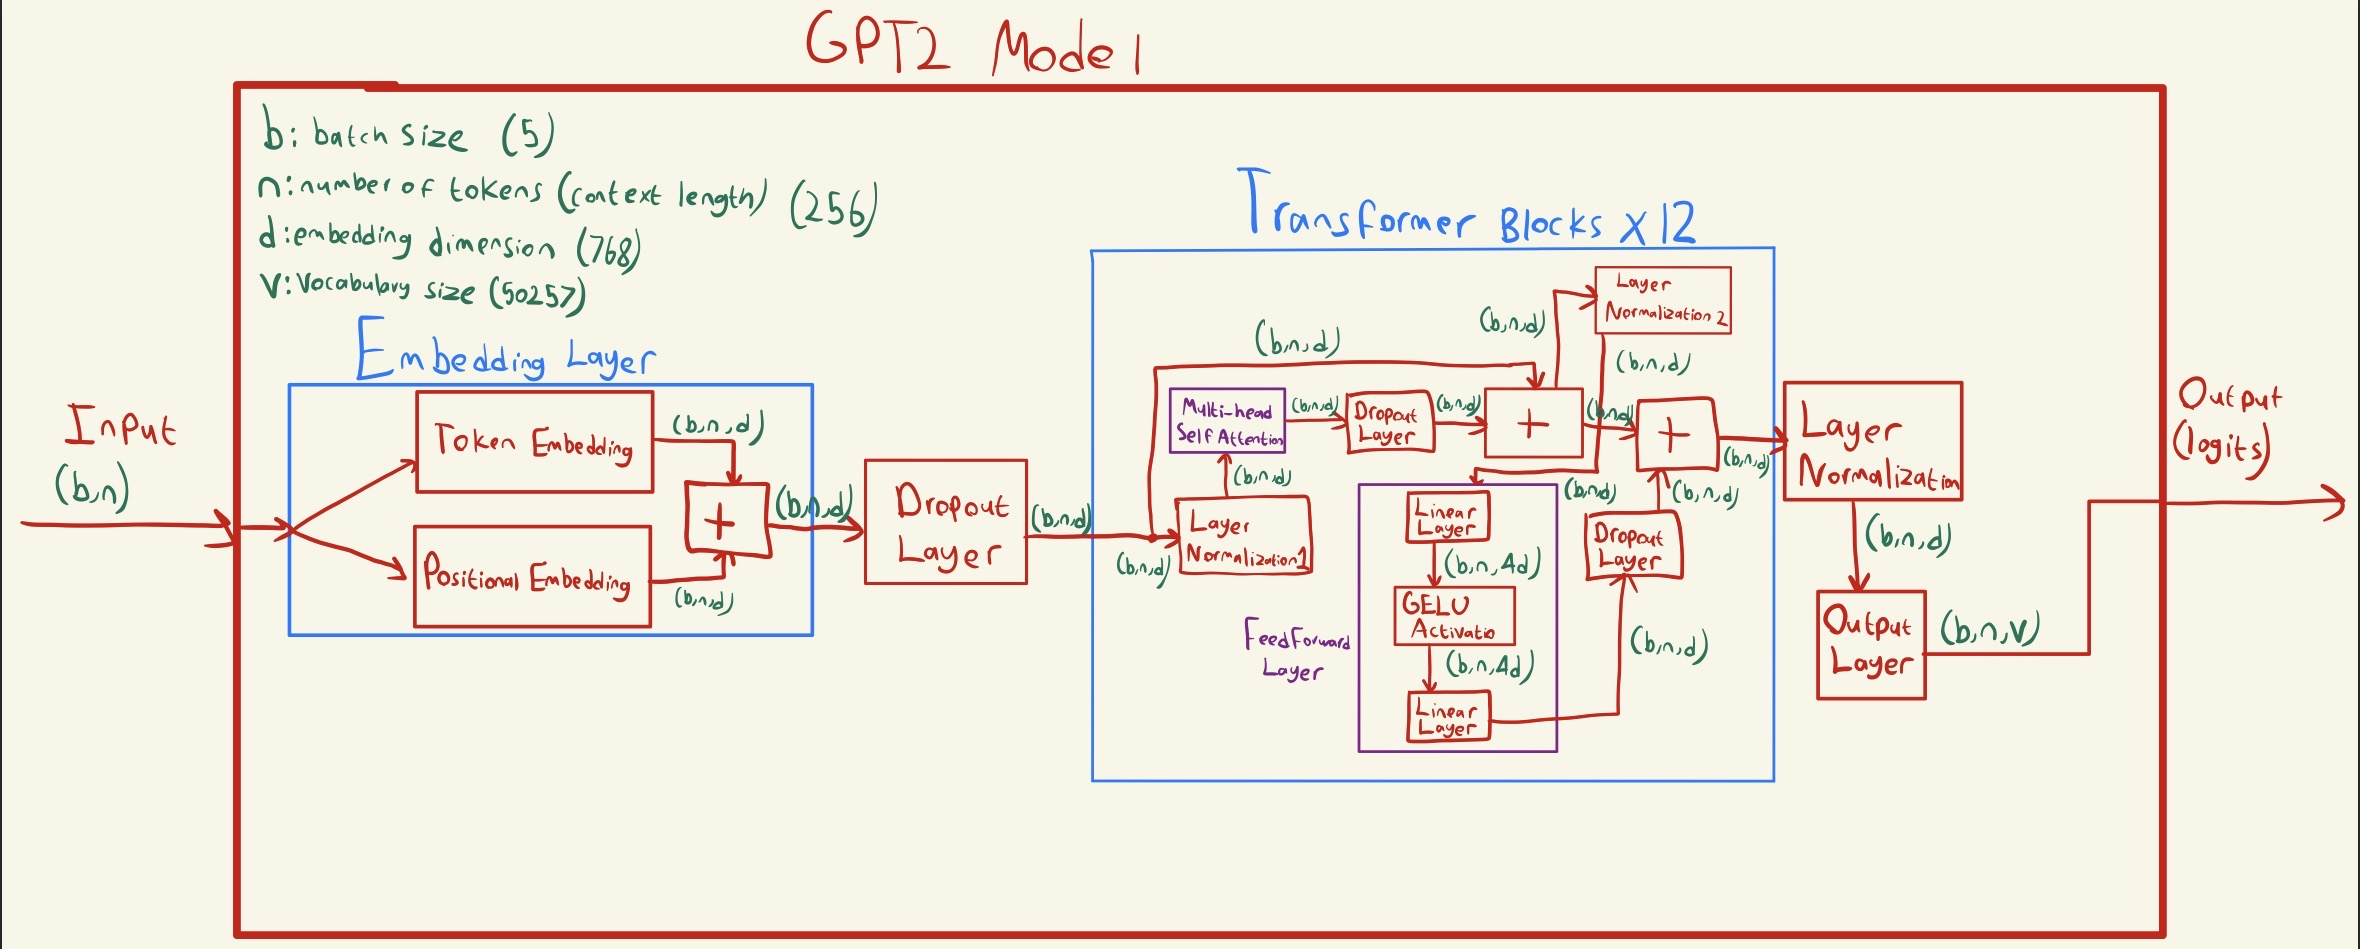

First, let's implement the Embedding Layer

In [15]:
class EmbeddingLayer(nn.Module):
  def __init__(self,cfg):
    super(EmbeddingLayer, self).__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
  def forward(self,x):
    tok_emb = self.tok_emb(x)
    pos_emb = self.pos_emb(torch.arange(x.size(1), device=x.device))
    result = tok_emb + pos_emb
    return result

Second, let's implement the FeedForward Layer

In [70]:
class FeedForwardLayer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            nn.GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

Third, let's implement the MultiHeadSelfAttention Layer according to the following architecture:
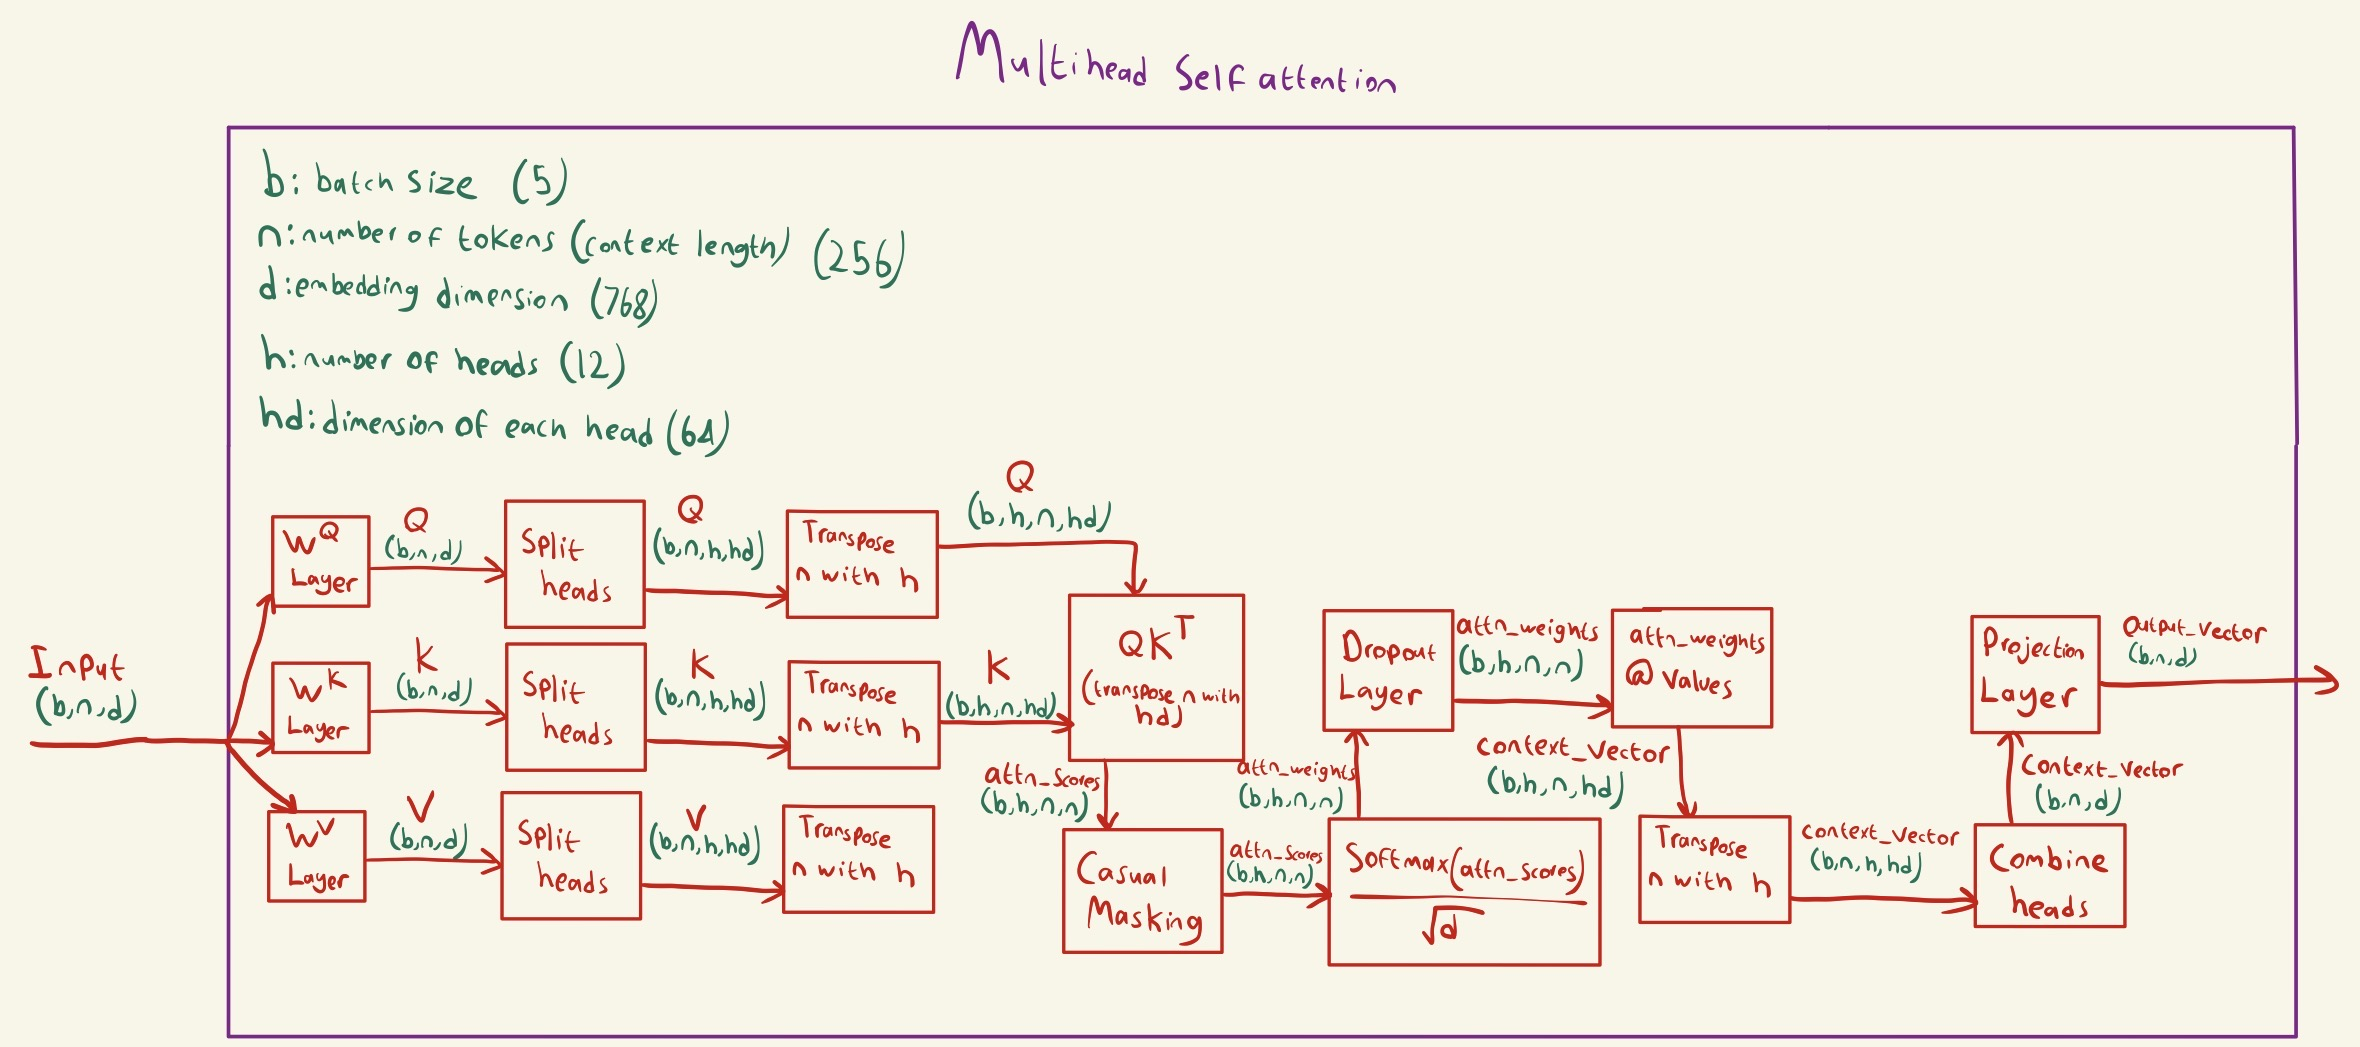

In [71]:
class MultiHeadAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        assert cfg["emb_dim"] % cfg["n_heads"] == 0, "embedding dimension must be divisible by number of heads"
        self.W_query = nn.Linear(cfg["emb_dim"], cfg["emb_dim"], bias=cfg["qkv_bias"]) #Wq
        self.W_key = nn.Linear(cfg["emb_dim"], cfg["emb_dim"], bias=cfg["qkv_bias"]) #Wk
        self.W_value = nn.Linear(cfg["emb_dim"], cfg["emb_dim"], bias=cfg["qkv_bias"]) #Wv
        self.out_proj = nn.Linear(cfg["emb_dim"], cfg["emb_dim"])  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(cfg["drop_rate"]) #Dropout layer to prevent overfitting
        self.register_buffer('mask', torch.triu(torch.ones(cfg["context_length"], cfg["context_length"]), diagonal=1))
        #Casual Masking to make the llm autoregressive

    def forward(self, x):
        b, num_tokens, d = x.shape #b is batch size

        keys = self.W_key(x) #K = X @ Wk
        queries = self.W_query(x) #Q = X @ Wq
        values = self.W_value(x) #V = X @ Wv
        num_heads = self.cfg["n_heads"]
        #Splitting the heads
        #Note that .view in PyTorch is the same as .reshape in numpy
        #Old shape: (batch_size, num_tokens, d)
        #New shape: (batch_size, num_tokens, num_heads, head_dim)
        head_dim = d // num_heads
        keys = keys.view(b, num_tokens, num_heads, head_dim)
        queries = queries.view(b, num_tokens, num_heads, head_dim)
        values = values.view(b, num_tokens, num_heads, head_dim)

        #Old shape: (batch_size, num_tokens, num_heads, head_dim)
        #New shape: (batch_size, num_heads, num_tokens, head_dim)
        #Why? Because for every head, we need to compute the attention scores for all tokens (not the opposite)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)  #attn_scores = QK^T

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        # We fill attention scores of future tokens with -∞ such that when we apply softmax it becomes 0
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / d**0.5, dim=-1) #attn_weights = softmax(attn_scores / sqrt(d))
        attn_weights = self.dropout(attn_weights) #apply dropout to prevent overfitting

        #Old shape: (batch_size, num_heads, num_tokens, head_dim)
        #New shape: (batch_size, num_tokens, num_heads, head_dim)
        #Done with self-attention, let's transpose things back
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, d)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

Fourth, let's implement a single transformer block

In [72]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(cfg)
        self.ff = FeedForwardLayer(cfg)
        self.norm1 = nn.LayerNorm(cfg["emb_dim"])
        self.norm2 = nn.LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

Finally, let's implement our GPT Model

In [32]:
class GPTModel(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.cfg = cfg
    self.transformers = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
    self.layers = nn.Sequential(EmbeddingLayer(cfg),
                                self.transformers,
                                nn.Dropout(cfg["drop_rate"]),
                                nn.LayerNorm(cfg["emb_dim"]),
                                nn.Linear(cfg["emb_dim"],cfg["vocab_size"]))
  def forward(self,x):
    return self.layers(x)

Now let's create a model

In [33]:
model = GPTModel(GPT_CONFIG)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters in the model (Millions): {total_params/1_000_000}")

Total number of parameters in the model (Millions): 162.469969


# Using the model to generate text

In [34]:
def generate_text_simple(model, text, tokenizer, num_new_nokens):
    model.eval()
    tokens = text_to_token_ids(text, tokenizer)
    for _ in range(num_new_nokens):
        # Crop current context if it exceeds the supported context length
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        context_length = model.cfg["context_length"]
        tokens_cropped = tokens[:, -context_length:]
        # Get the predictions
        with torch.no_grad():
            logits = model(tokens_cropped)

        # Focus only on the last token
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the token with the highest logit
        output_token = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)
        # Append the new token to the result
        tokens = torch.cat((tokens, output_token), dim=1)  # (batch, n_tokens+1)
    result = token_ids_to_text(tokens, tokenizer)
    return result

In [35]:
generate_text_simple(
    model=model,
    text="Every effort moves you",
    tokenizer=tokenizer,
    num_new_nokens=10
)

'Every effort moves youTomKnItemImageCSS rapadows Selection799smoking hydraulic'

Wait why is the output weird?
Oh we did not train the model yet

#Training

In [43]:
n = 5 #number of epochs
optimizer = optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1) #optimizer
for epoch in range(n):
  model.train()
  epoch_loss = 0.0
  for input, target in train_loader:
    logits = model(input) #forward pass
    loss = F.cross_entropy(logits.flatten(0, 1), target.flatten()) #calculate loss
    epoch_loss += loss.item() #add loss to epoch loss
    optimizer.zero_grad() #gradient = 0
    loss.backward() #calculate gradient
    optimizer.step() #update weights
  print("Epoch: ",epoch," Loss: ",epoch_loss)

Epoch:  0  Loss:  82.69500827789307
Epoch:  1  Loss:  59.86580753326416
Epoch:  2  Loss:  61.022316455841064
Epoch:  3  Loss:  45.63687038421631
Epoch:  4  Loss:  37.87123131752014


In [44]:
generate_text_simple(
    model=model,
    text="Every effort moves you",
    tokenizer=tokenizer,
    num_new_nokens=10
)

'Every effort moves you know to have my--and a little it--'

- See, the output is now better!
- The more we train it, the better the output will be (unless if the model has overfit the data)